# Classical

In [205]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample
from scipy.linalg import hadamard
from imblearn.over_sampling import SMOTE
from matplotlib import pyplot as plt
%matplotlib inline
from IPython.display import clear_output
import pandas as pd
pd.set_option('display.max_columns', None)
import seaborn as sns
import numpy as np
import random
import prince
from typing import TypeAlias, Union, List
from ucimlrepo import fetch_ucirepo

from numpy.typing import ArrayLike
MatrixLike: TypeAlias = Union[
    ArrayLike,
    pd.DataFrame
]

In [206]:
lab_train = pd.read_csv('lab1-train-processed.csv')
lab_test = pd.read_csv('lab1-test-processed.csv')

display(lab_train)
display(lab_test)

y_train = lab_train['class']
y_test = lab_test['class']
X_train = lab_train.drop('class', axis=1)
X_test = lab_test.drop('class', axis=1)

top_cols = [col for col in X_train.columns if col.startswith('X')]
famd_cols = [col for col in X_train.columns if col.startswith('C')]

,class,X2,C0,X6,C1,X10,C2,X17,C3,X3,C4,X4,C5,X7,C6,X5_1,C7,X13,C8,X15_1,C9
0,6,133.907314,-1.468208,2.989235,0.276903,1.745602,-1.991880,18.008365,1.665992,3.000000,0.229429,0.625350,0.430481,2.923792,-0.388358,0,-0.027717,1.536555,0.191164,0,0.392011
1,4,82.365608,0.714526,1.810804,-0.618230,1.608400,-1.650259,22.339190,-1.390567,1.000000,0.296710,2.000000,1.706740,2.598632,1.324411,0,-0.891510,0.292093,0.010644,0,0.161591
2,5,121.134488,-2.238483,2.811050,0.281797,1.867410,-0.672576,23.274485,0.569318,2.657720,0.563710,0.000000,-0.540056,2.104696,-0.125796,1,0.702596,0.870056,-0.008144,0,-0.410528
3,3,79.125521,0.405247,2.000000,1.650545,1.800000,-0.510070,17.652645,-1.338986,1.000000,1.324808,1.000000,-0.165750,2.000000,0.540286,1,0.183907,2.000000,-0.076974,1,-0.326369
4,5,118.193323,-2.002027,2.191108,0.604417,1.788586,-0.415796,24.566325,0.107035,2.993856,0.729268,0.145284,-0.443735,2.444917,-0.272059,1,0.404912,1.388962,-0.046416,0,-0.086728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1683,3,66.859042,1.451516,2.000000,0.303109,1.640000,0.447478,21.226280,-1.254997,3.000000,-1.246056,1.000000,-0.086139,1.000000,-0.521961,1,-0.363859,0.000000,-0.504150,0,-1.602967
1684,4,98.739188,-0.881631,2.000000,1.897943,1.732694,-0.426703,21.494374,-1.222413,2.993623,-0.707082,1.529423,0.645786,2.326635,-0.720979,1,-1.006865,2.236586,0.317045,0,-0.150458
1685,4,95.973811,-1.011257,2.000000,2.155115,1.741353,-0.333581,21.005434,-0.944677,3.000000,-0.354342,1.229474,0.727815,2.697661,-1.109787,1,-0.995599,2.614909,0.431379,0,-0.052324
1686,0,79.634810,-1.090697,1.993101,0.495533,1.745950,-0.022242,24.969213,-0.348468,3.171082,0.713230,0.022245,-0.693482,2.364498,-0.282761,1,0.378846,1.224743,-0.208985,0,0.082620


,class,X2,C0,X6,C1,X10,C2,X17,C3,X3,C4,X4,C5,X7,C6,X5_1,C7,X13,C8,X15_1,C9
0,0,65.517027,0.484487,2.374640,-1.847356,1.449559,1.590055,36.591143,0.396030,3.000000,-0.189425,0.480813,0.340385,2.000000,-1.107690,0,-0.227402,2.892922,0.179947,0,1.047396
1,4,80.321076,0.109128,2.766320,-3.276887,1.582523,2.075080,42.412773,-0.221815,1.317884,-0.121852,0.000000,1.570310,1.967408,-1.178837,0,-0.372068,0.990642,0.527927,0,-0.123479
2,6,103.939346,0.073094,3.000000,-1.897598,1.617390,-1.372753,24.228630,0.688670,3.000000,-0.626943,0.541309,-0.320001,1.292479,0.558842,0,0.421557,0.000000,-0.395995,0,-0.056059
3,3,64.881769,-0.796613,3.000000,1.193776,1.780000,1.134938,24.192968,0.908599,3.000000,-0.281191,1.000000,0.873024,2.000000,2.358295,1,-2.152621,1.000000,0.820595,0,2.345712
4,4,103.919796,-1.670365,2.253707,0.339208,1.785718,-0.616425,23.199143,-0.033524,3.000000,0.776164,0.175694,-0.464756,2.524432,0.078508,1,0.435049,0.582160,-0.180257,0,0.012671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
418,6,106.455606,-0.521648,3.009608,-1.567272,1.629191,-1.414409,27.070496,1.220609,3.000000,0.150220,0.555468,0.401723,2.654702,0.222386,0,0.132335,0.000000,-0.099324,0,0.446954
419,3,60.350897,0.979537,2.000000,0.074900,1.650000,0.661700,22.742513,-0.687676,3.000000,-0.106647,0.000000,0.040351,2.000000,-1.063919,1,-0.124470,0.000000,-0.350357,0,-1.211942
420,4,95.104136,-0.641643,2.000000,1.167839,1.701986,-0.225637,22.698244,-1.236276,3.000000,-0.591072,1.066603,0.349936,2.021270,-0.624453,1,-0.686549,1.814869,0.152797,0,-0.284635
421,4,80.293832,0.202996,2.000000,-3.692421,1.529060,1.813763,40.067806,-0.553698,3.000000,-0.338952,0.000000,-0.623399,1.000000,0.189557,0,0.530507,0.000000,-0.555358,0,0.418316


In [207]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train[famd_cols[:2]])
X_test_scaled = scaler.transform(X_test[famd_cols[:2]])

lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)
print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.21      0.14      0.17        58
           1       0.11      0.10      0.11        58
           2       0.43      0.67      0.52        54
           3       0.33      0.19      0.24        58
           4       0.13      0.03      0.05        70
           5       0.41      0.77      0.53        60
           6       0.51      0.66      0.58        65

    accuracy                           0.36       423
   macro avg       0.30      0.36      0.31       423
weighted avg       0.30      0.36      0.31       423



In [208]:
svc = SVC(kernel='rbf', class_weight='balanced')
svc.fit(X_train_scaled, y_train)
y_pred = svc.predict(X_test_scaled)
print("SVC Classification Report:")
print(classification_report(y_test, y_pred))

SVC Classification Report:
              precision    recall  f1-score   support

           0       0.20      0.05      0.08        58
           1       0.31      0.28      0.29        58
           2       0.45      0.74      0.56        54
           3       0.47      0.38      0.42        58
           4       0.49      0.40      0.44        70
           5       0.59      0.75      0.66        60
           6       0.65      0.88      0.75        65

    accuracy                           0.50       423
   macro avg       0.45      0.50      0.46       423
weighted avg       0.46      0.50      0.46       423



In [269]:
def build_ecoc_matrix(n_classes: int, n_learners: int) -> np.ndarray:
    n = 2 ** int(np.ceil(np.log2(n_learners)) + 1)

    H = hadamard(n)[:n_classes]

    code = ((H + 1) // 2).astype(int)

    mask = (code.sum(0) > 0) & (code.sum(0) < n_classes)
    code = code[:, mask]

    ecoc = np.array(code[:, :n_learners]).T

    inc = -1
    for i in range(len(ecoc)):
        if np.array_equal(ecoc[i], ecoc[0]):
            inc += 1
        ecoc[i] = np.roll(ecoc[i], inc)
    return ecoc

In [210]:
ecoc = build_ecoc_matrix(7, 14)

final_preds = np.array([[0] * ecoc.shape[1]] * len(y_test))
for i, code in enumerate(ecoc):
    clf = LogisticRegression(max_iter=1000, class_weight='balanced')
    clf.fit(X_train_scaled, y_train.apply(lambda x: code[x]))
    y_pred = clf.predict(X_test_scaled)

    # # Individual classification report for each binary classifier
    # print(f"Classifier {i+1} (Code: {code}):")
    # print(classification_report(y_test.apply(lambda x: code[x]), y_pred))

    for j, pred in enumerate(y_pred):
        final_preds[j][code == pred] += 1

final_preds = np.argmax(final_preds, axis=1)
print("Logistic Regression Ensemble Classification Report:")
print(classification_report(y_test, final_preds, zero_division=0))

Logistic Regression Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.22      0.10      0.14        58
           1       1.00      0.02      0.03        58
           2       0.32      0.78      0.45        54
           3       0.00      0.00      0.00        58
           4       0.00      0.00      0.00        70
           5       0.26      0.73      0.39        60
           6       0.41      0.57      0.47        65

    accuracy                           0.31       423
   macro avg       0.32      0.31      0.21       423
weighted avg       0.31      0.31      0.21       423



In [211]:
ecoc = build_ecoc_matrix(7, 14)

final_preds = np.array([[0] * ecoc.shape[1]] * len(y_test))
for i, code in enumerate(ecoc):
    clf = SVC(kernel='rbf', class_weight='balanced')
    clf.fit(X_train_scaled, y_train.apply(lambda x: code[x]))
    y_pred = clf.predict(X_test_scaled)

    # # Individual classification report for each binary classifier
    # print(f"Classifier {i+1} (Code: {code}):")
    # print(classification_report(y_test.apply(lambda x: code[x]), y_pred))

    for j, pred in enumerate(y_pred):
        final_preds[j][code == pred] += 1

final_preds = np.argmax(final_preds, axis=1)
print("SVC Ensemble Classification Report:")
print(classification_report(y_test, final_preds, zero_division=0))

SVC Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.34      0.28      0.30        58
           1       0.18      0.03      0.06        58
           2       0.58      0.61      0.59        54
           3       0.54      0.52      0.53        58
           4       0.43      0.49      0.46        70
           5       0.56      0.73      0.63        60
           6       0.60      0.86      0.70        65

    accuracy                           0.51       423
   macro avg       0.46      0.50      0.47       423
weighted avg       0.46      0.51      0.47       423



# Quantum

In [212]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.templates import AngleEmbedding, IQPEmbedding, StronglyEntanglingLayers, BasicEntanglerLayers
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

import time
import copy
from typing import Literal

plt.rcParams["figure.figsize"] = (12, 6)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = "cpu"

print(f"Using device: {DEVICE}\n")
qml.about()

Using device: cpu

Name: pennylane
Version: 0.45.0
Summary: PennyLane is a cross-platform Python library for quantum computing, quantum machine learning, and quantum chemistry. Train a quantum computer the same way as a neural network.
Home-page: 
Author: 
License: 
Location: /home/edwar/.pyenv/versions/3.14.5/lib/python3.14/site-packages
Platform info:           Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.39
Python version:          3.14.5
Numpy version:           2.4.6
Scipy version:           1.17.1
JAX version:             None
Catalyst version:        None
Installed devices:
- lightning.gpu (pennylane_lightning_gpu-0.45.0)
- default.clifford (pennylane-0.45.0)
- default.gaussian (pennylane-0.45.0)
- default.mixed (pennylane-0.45.0)
- default.qubit (pennylane-0.45.0)
- default.qutrit (pennylane-0.45.0)
- default.qutrit.mixed (pennylane-0.45.0)
- default.tensor (pennylane-0.45.0)
- null.qubit (pennylane-0.45.0)
- reference.qubit (pennylane-0.45.0)
- lightning.qubit (pe

In [224]:
n_qubits = 2
n_layers = 2

if DEVICE == "cuda":
    dev = qml.device("lightning.gpu", wires=n_qubits)
else:
    dev = qml.device("default.qubit", wires=n_qubits)
    
scaler = MinMaxScaler(feature_range=(0, np.pi))

<default.qubit device (wires=2) at 0x797654f2bf70>


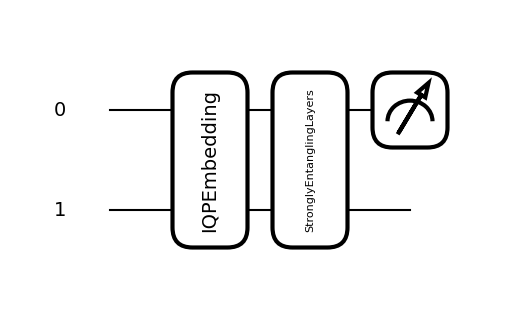

In [225]:
@qml.qnode(dev, interface='torch', diff_method='best')
def circuit(inputs: torch.Tensor, weights: torch.Tensor) -> qml.measurements.ProbabilityMP:
    IQPEmbedding(inputs, wires=range(n_qubits), n_repeats=2)
    StronglyEntanglingLayers(weights, wires=range(n_qubits))

    return qml.probs(wires=[0])

weight_shapes = {
    "weights": (n_layers, n_qubits, 3)
}

qml.draw_mpl(circuit)(np.zeros(n_qubits), np.zeros(weight_shapes["weights"]))
print(circuit.device)

qlayer = qml.qnn.TorchLayer(circuit, weight_shapes=weight_shapes)

In [284]:
class BinaryVQC(nn.Module):
    def __init__(self, qlayer: qml.qnn.TorchLayer):
        super().__init__()
        self.qlayer = qlayer

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        probs = self.qlayer(x)

        half = probs.shape[1] // 2
        return torch.stack([probs[:, :half].sum(dim=1), probs[:, half:].sum(dim=1)], dim=1)
        
    
    def fit(
        self,
        train_loader: torch.utils.data.DataLoader,
        test_loader: torch.utils.data.DataLoader = None,
        epochs: int = 100,
        lr: float = 0.01,
        optimizer_cls: torch.optim.Optimizer = torch.optim.Adam,
        criterion: nn.Module = nn.NLLLoss(),
        patience: int = 10,
        warmup: int = 15,
        min_delta: float = 1e-3,
        plot: bool = True,
        title_prefix: str = "",
        restore_best: bool = True,
        verbose: bool = True,
    ):
        self.to(DEVICE)

        optimizer = optimizer_cls(self.parameters(), lr=lr)

        best_state = None
        patience_counter = 0

        train_losses = []
        val_losses = []
        best_loss = float("inf")

        time_start = time.time()
        for epoch in range(epochs):
            # Training
            epoch_loss = 0.0
            self.train()
            for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
                if verbose:
                    print(f"[Epoch {epoch + 1}/{epochs}] Batch {batch_idx + 1}/{len(train_loader)}", end="\r")

                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                optimizer.zero_grad()

                probs = self(X_batch)
                loss = criterion(probs, y_batch)

                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()

            avg_train_loss = epoch_loss / len(train_loader)
            train_losses.append(avg_train_loss)

            # Validation
            if test_loader:
                val_loss = 0.0
                correct = 0
                total = 0
                self.eval()
                with torch.no_grad():
                    for X_batch, y_batch in test_loader:
                        X_batch = X_batch.to(DEVICE)
                        y_batch = y_batch.to(DEVICE)

                        probs = self(X_batch)
                        loss = criterion(probs, y_batch)

                        val_loss += loss.item()

                        preds = probs.argmax(dim=1)
                        correct += (preds == y_batch).sum().item()
                        total += y_batch.size(0)

                avg_val_loss = val_loss / len(test_loader)
                val_acc = correct / total

                val_losses.append(avg_val_loss)

            # Plot
            if plot:
                clear_output(wait=True)
                plt.figure(figsize=(10, 6))
                plt.plot(train_losses, label="Train Loss")
                if test_loader:
                    plt.plot(val_losses, label="Validation Loss")
                plt.xlabel("Epoch")
                plt.ylabel("Loss")
                plt.title(f"{title_prefix}Training {'and Validation' if test_loader else ''} Loss")
                plt.legend()
                plt.grid(True)
                plt.xlim(0, max(1, len(train_losses) - 1))
                plt.show()

            if verbose:
                print(f"[Epoch {epoch + 1}/{epochs}] Train Loss: {avg_train_loss:.4f} {f'| Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.3f}' if test_loader else ''}")
            
            # Early stopping
            monitor_loss = avg_val_loss if test_loader else avg_train_loss
            if epoch >= warmup:
                if monitor_loss < best_loss - min_delta:
                    best_loss = monitor_loss
                    patience_counter = 0

                    if restore_best:
                        best_state = copy.deepcopy(self.state_dict())
                else:
                    patience_counter += 1

                if patience_counter >= patience:
                    if verbose:
                        print(f"Early stopping at epoch {epoch + 1}")
                    break
            else:
                if monitor_loss < best_loss:
                    best_loss = monitor_loss

                    if restore_best:
                        best_state = copy.deepcopy(self.state_dict())

        if restore_best and best_state is not None:
            self.load_state_dict(best_state)

        self.training_time = time.time() - time_start
        if verbose:
            print(f"Total training time: {self.training_time:.2f} seconds")

        self.train_losses = train_losses
        self.val_losses = val_losses
        self.best_loss = best_loss

    def predict(self, X: torch.Tensor) -> torch.Tensor:
        self.eval()
        with torch.no_grad():
            probs = self(X.to(DEVICE))
            preds = probs.argmax(dim=1)
            return preds.cpu()
    
    def predict_proba(self, X: torch.Tensor) -> torch.Tensor:
        self.eval()
        with torch.no_grad():
            probs = self(X.to(DEVICE))
            return probs.cpu()

    def score(self, X: torch.Tensor, y: torch.Tensor) -> float:
        preds = self.predict(X)
        return accuracy_score(y, preds)

In [227]:
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets
label_names = sorted(y[y.columns[0]].unique())
label_to_int = {label: idx for idx, label in enumerate(label_names)}
int_to_label = {idx: label for idx, label in enumerate(label_names)}
print(f"Label mapping: {label_to_int}")
y = y[y.columns[0]].map(label_to_int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

pca = prince.PCA(n_components=2, n_iter=5, random_state=2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

X_tr = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32).to(DEVICE)
X_te = torch.tensor(scaler.transform(X_test), dtype=torch.float32).to(DEVICE)
y_tr = torch.tensor(y_train.values, dtype=torch.long).to(DEVICE)
y_te = torch.tensor(y_test.values, dtype=torch.long).to(DEVICE)

trainloader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)
testloader = DataLoader(TensorDataset(X_te, y_te), batch_size=32, shuffle=False)

Label mapping: {'B': 0, 'M': 1}


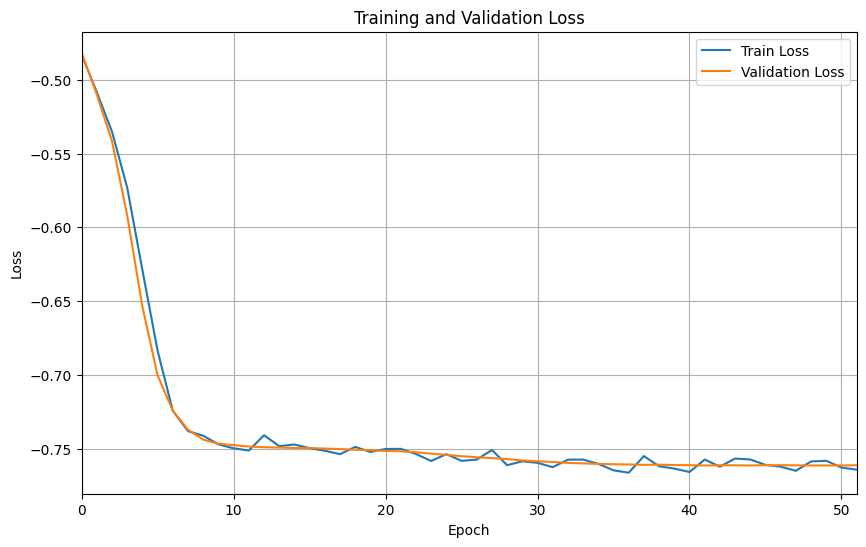

[Epoch 52/100] Train Loss: -0.7643 | Val Loss: -0.7613 | Val Acc: 0.877
Early stopping at epoch 52
Total training time: 12.02 seconds


In [228]:
model = BinaryVQC(qlayer)
model.fit(trainloader, testloader)

In [229]:
train_score = model.score(X_tr, y_tr)

print(f"Training Accuracy: {train_score:.2f}")
print("Classification Report:\n", classification_report(y_te, model.predict(X_te), zero_division=0))

Training Accuracy: 0.85
Classification Report:
               precision    recall  f1-score   support

           0       0.84      1.00      0.91        72
           1       1.00      0.67      0.80        42

    accuracy                           0.88       114
   macro avg       0.92      0.83      0.86       114
weighted avg       0.90      0.88      0.87       114



## Ensemble

In [290]:
from tabnanny import verbose

from sympy import plot


class QuECOC:
    def __init__(self, n_classes: int, n_learners: int = None, circuits: List[qml.qnn.TorchLayer] = None):
        self.n_classes = n_classes
        self.n_learners = n_learners if n_learners else n_classes * 2
        self.circuits = circuits

        self.ecoc = build_ecoc_matrix(self.n_classes, self.n_learners)
        self.classifiers = []

    def fit(self, X: MatrixLike, y: ArrayLike, X_test: MatrixLike = None, y_test: ArrayLike = None, plot: bool = False, verbose: bool = False, **fit_params):
        X_tr = torch.tensor(X, dtype=torch.float32).to(DEVICE)

        if X_test is not None:
            X_te = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)

        for i, circuit in enumerate(self.circuits):
            code = self.ecoc[i]
            y_train = y.apply(lambda x: code[x])
            y_tr = torch.tensor(y_train, dtype=torch.long).to(DEVICE)

            if X_test is not None and y_test is not None:
                y_te = torch.tensor(y_test.apply(lambda x: code[x]).values, dtype=torch.long).to(DEVICE)
                testloader = DataLoader(TensorDataset(X_te, y_te), batch_size=32, shuffle=False)
            else:
                testloader = None

            trainloader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=32, shuffle=True)

            clf = BinaryVQC(qlayer=circuit)
            clf.fit(trainloader, testloader, title_prefix=f"Classifier {i + 1}/{self.n_learners}: ", plot=plot, verbose=verbose, **fit_params)
            # clf.report = classification_report(y_test.apply(lambda x: code[x]) if y_test is not None else y_train, clf.predict(X_te), zero_division=0)

            self.classifiers.append(clf)

        if plot:
            clear_output(wait=True)
            plt.figure(figsize=(10, 6))
            for j, clf in enumerate(self.classifiers):
                plt.plot(clf.val_losses, label=f"Classifier {j + 1} (Code: {self.ecoc[j]})")
            plt.xlabel("Epoch")
            plt.ylabel("Validation Loss")
            plt.title("Validation Loss for Each Classifier")
            plt.xlim(0, max(1, max(len(clf.val_losses) for clf in self.classifiers) - 1))
            plt.legend()
            plt.grid(True)
            plt.show()

        if verbose:
            print(f"Total training time after fitting {self.n_learners} classifiers: {sum(clf.training_time for clf in self.classifiers):.2f} seconds")

    def predict(self, X: MatrixLike) -> np.ndarray:
        with torch.no_grad():
            X_tr = torch.tensor(X, dtype=torch.float32).to(DEVICE)

            final_preds = np.array([[0] * self.n_classes] * len(X))
            for i, clf in enumerate(self.classifiers):
                preds = clf.predict(X_tr)

                for j, pred in enumerate(preds):
                    final_preds[j][self.ecoc[i] == pred.item()] += 1

            return np.array(final_preds).argmax(axis=1).tolist()
    
    def predict_proba(self, X: MatrixLike) -> np.ndarray:
        with torch.no_grad():
            X_tr = torch.tensor(X, dtype=torch.float32).to(DEVICE)
            
            final_preds = np.array([[0.0] * self.n_classes] * len(X))
            for i, clf in enumerate(self.classifiers):
                preds = clf.predict_proba(X_tr)

                for j, pred in enumerate(preds):
                    final_preds[j][self.ecoc[i] == 0] += pred[0].item()
                    final_preds[j][self.ecoc[i] == 1] += pred[1].item()

            return np.array(final_preds) / self.n_learners
    
    def score(self, X, y):
        preds = self.predict(X)
        return accuracy_score(y.values, preds)

In [231]:
iris = fetch_ucirepo(id=53)

X = iris.data.features
y = iris.data.targets
label_names = sorted(y[y.columns[0]].unique())
label_to_int = {label: idx for idx, label in enumerate(label_names)}
int_to_label = {idx: label for idx, label in enumerate(label_names)}
print(f"Label mapping: {label_to_int}")
y = y[y.columns[0]].map(label_to_int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

pca = prince.PCA(n_components=2, n_iter=5, random_state=2)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Label mapping: {'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}


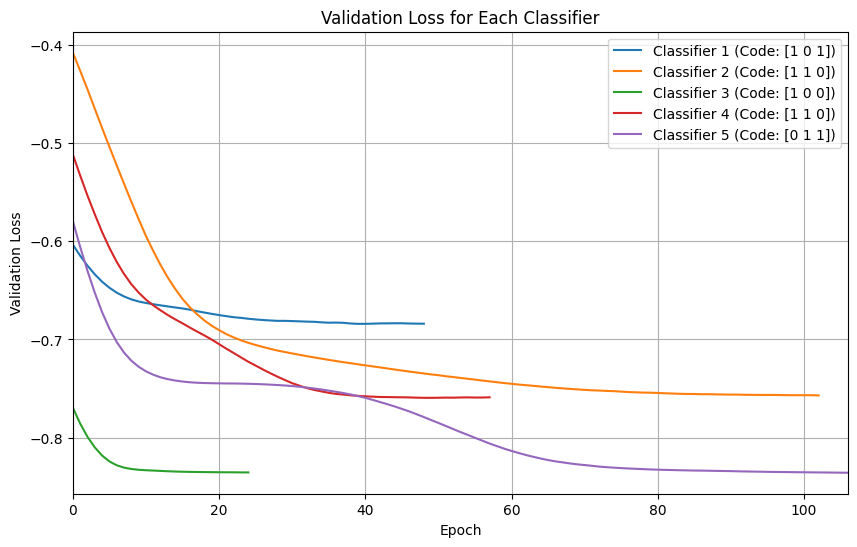

Total training time after fitting 5 classifiers: 33.03 seconds


In [232]:
circuits = [qml.qnn.TorchLayer(circuit, weight_shapes=weight_shapes) for _ in range(5)]
ens = QuECOC(circuits=circuits, n_classes=len(label_names))
ens.fit(X_train_scaled, y_train, X_test_scaled, y_test, epochs=200)

In [233]:
train_score = ens.score(X_train_scaled, y_train)

print(f"Training Accuracy: {train_score:.2f}")
print("Classification Report:\n", classification_report(y_test, ens.predict(X_test_scaled), zero_division=0))

Training Accuracy: 0.82
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.71      1.00      0.83        10
           2       1.00      0.60      0.75        10

    accuracy                           0.87        30
   macro avg       0.90      0.87      0.86        30
weighted avg       0.90      0.87      0.86        30



<default.qubit device (wires=2) at 0x797654f2bf70>


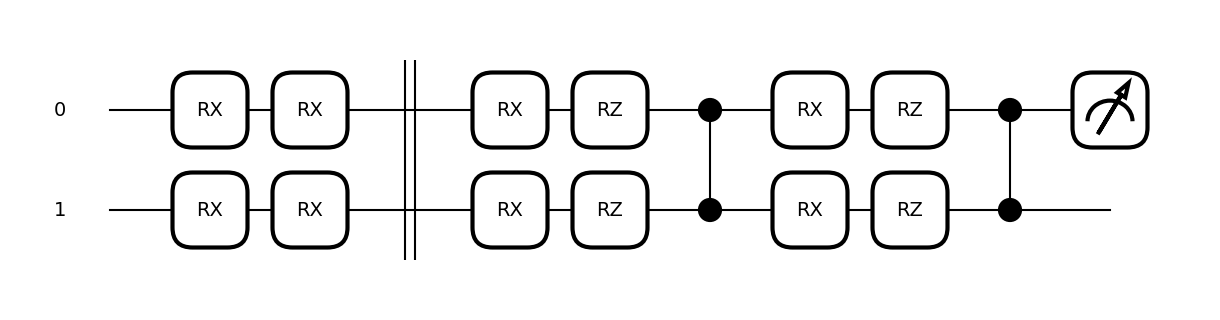

In [234]:
def reuploading_qlayer(
    n_qubits: int,
    feats_per_qubit: int,
    reuploads: int = 2,
    entangle_between_reuploads: bool = True,
    trainable_layers: int | list[int] = None,
    ranges: int | list[int] | list[list[int]] = 1,
    rot_gates: list[type[qml.RX]] = None,
    ent_gate: type[qml.CZ] = qml.CZ,
    measurement_wires: list[int] = None,
):
    """
    Dynamic feature-reuploading quantum layer.

    Args:
        n_qubits: Number of qubits in the circuit.
        feats_per_qubit: Number of classical features loaded onto each qubit per reupload.
        reuploads: Number of times the feature loading and entangling blocks are repeated.
        entangle_between_reuploads: Whether to apply entanglement between feature loading blocks. If False, entanglement is only applied after the last feature loading block.
        trainable_layers: Number of trainable layers of Rot gates to apply after each feature loading block. Can also be a list specifying the number of trainable layers for each reupload.
        ranges: Range(s) for the strongly entangling pattern. Can be a single int applied to all reuploads, a list of ints specifying the range for each reupload, or a list of lists specifying the range for each layer within each reupload.
        rot_gates: List of single-qubit rotation gate types to use for feature encoding and trainable layers.
        ent_gate: The two-qubit gate used for entanglement (e.g., qml.CNOT, qml.CZ).
        measurement_wires: List of wires to measure at the end of the circuit.
    """

    n_features = n_qubits * feats_per_qubit

    if trainable_layers is None:
        trainable_layers = [0] * (reuploads - 1) + [2]
    if isinstance(trainable_layers, int):
        if entangle_between_reuploads:
           trainable_layers = [trainable_layers] * reuploads
        else:
           trainable_layers = [0] * (reuploads - 1) + [trainable_layers]
    else:
        if entangle_between_reuploads and len(trainable_layers) != reuploads:
            raise ValueError(
                f"`trainable_layers` must be either an int or a list of length equal to `reuploads`. "
                f"Got trainable_layers={trainable_layers} and reuploads={reuploads}."
            )
        elif not entangle_between_reuploads:
            raise ValueError(
                f"When `entangle_between_reuploads` is False, `trainable_layers` must be an int. "
                f"Got trainable_layers={trainable_layers}."
            )

    if sum(trainable_layers) == 0:
        raise ValueError("At least one trainable layer is required for the circuit to be trainable.")
    
    if isinstance(ranges, int):
        ranges = [ranges] * reuploads
    elif len(ranges) != reuploads:
        raise ValueError(
            f"`ranges` must be either an int or a list of length equal to `reuploads`. "
            f"Got ranges={ranges} and reuploads={reuploads}."
        )

    if len(ranges) != reuploads:
        raise ValueError(
            f"`ranges` must have length equal to `reuploads`. "
            f"Got len(ranges)={len(ranges)} and reuploads={reuploads}."
        )
    
    if rot_gates is None:
        rot_gates = [qml.RX, qml.RZ]
    
    if measurement_wires is None:
        measurement_wires = [0]

    def feature_block(inputs):
        for q in range(n_qubits):
            for f in range(feats_per_qubit):
                feature_idx = q * feats_per_qubit + f
                gate = rot_gates[f % len(rot_gates)]
                gate(inputs[..., feature_idx], wires=q)

    def strongly_entangling_block(weights, trainable_layers, ranges, start_idx):
        repeats = max(trainable_layers, 1)

        if isinstance(ranges, int):
            ranges = [ranges] * repeats
        elif len(ranges) != repeats:
            raise ValueError(
                f"`ranges` must be either an int or a list of length equal to `trainable_layers`. "
                f"Got ranges={ranges} and trainable_layers={trainable_layers}."
            )
        
        for layer in range(repeats):
            for q in range(n_qubits):
                if trainable_layers > 0:
                    # Apply trainable Rot gates for this layer
                    for g, gate in enumerate(rot_gates):
                        gate(weights[start_idx + layer, q, g], wires=q)

            if n_qubits > 1:
                for q in range(n_qubits - 1):
                    if ranges[layer] == 0 or ranges[layer] >= n_qubits:
                        raise ValueError(
                            f"Invalid range value: {ranges[layer]}. "
                            f"Range must be between 1 and {n_qubits - 1} (n_qubits-1)."
                        )

                    # Apply entangling pattern for this layer
                    control = q
                    target = (q + ranges[layer]) % n_qubits
                    ent_gate(wires=[control, target])

                if n_qubits > 2:
                    ent_gate(wires=[n_qubits - 1, 0])

    @qml.qnode(dev, interface="torch", diff_method="best")
    def circuit(inputs, weights):
        layer_idx = 0
        for r in range(reuploads):
            feature_block(inputs)
            if r == reuploads - 1:
                qml.Barrier(wires=range(n_qubits), only_visual=True)
            if entangle_between_reuploads or r == reuploads - 1:
                strongly_entangling_block(weights, trainable_layers[r], ranges[r], layer_idx)
            layer_idx += trainable_layers[r]

        return qml.probs(wires=measurement_wires)

    weight_shapes = {
        "weights": (sum(trainable_layers), n_qubits, len(rot_gates))
    }

    qlayer = qml.qnn.TorchLayer(circuit, weight_shapes)

    return qlayer, circuit, weight_shapes, n_features

qlayer, circuit, weight_shapes, n_features = reuploading_qlayer(
    n_qubits=2,
    feats_per_qubit=1,
    reuploads=2,
    entangle_between_reuploads=False,
    trainable_layers= 2,
    ranges=1,
    measurement_wires=[0],
)

qml.draw_mpl(circuit)(torch.zeros(n_features), torch.zeros(weight_shapes["weights"]))
print(circuit.device)

In [270]:
lab_train = pd.read_csv('lab1-train-processed.csv')
lab_test = pd.read_csv('lab1-test-processed.csv')

y_train = lab_train['class']
y_test = lab_test['class']
X_train = lab_train.drop('class', axis=1)
X_test = lab_test.drop('class', axis=1)

top_cols = [col for col in X_train.columns if col.startswith('X')]
famd_cols = [col for col in X_train.columns if col.startswith('C')]

scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train_scaled = scaler.fit_transform(X_train[famd_cols[:6]])
X_test_scaled = scaler.transform(X_test[famd_cols[:6]])

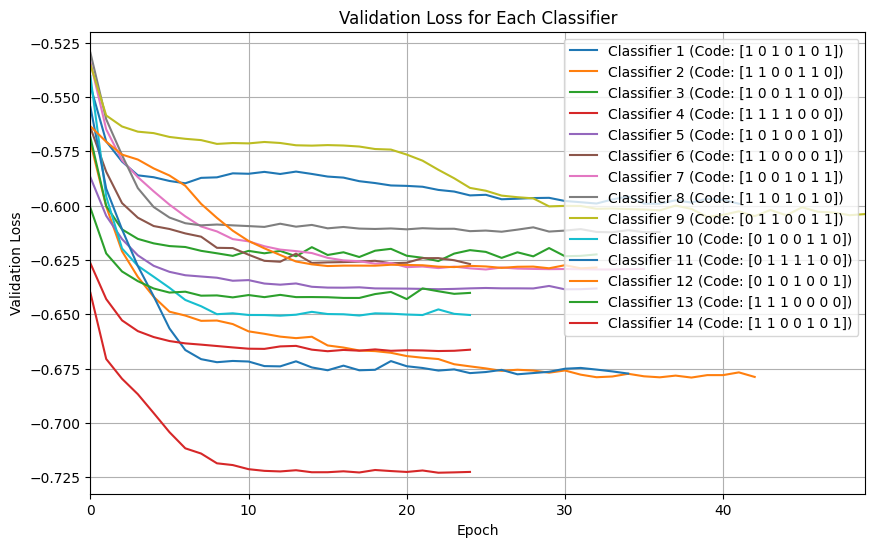

Total training time after fitting 14 classifiers: 264.16 seconds


In [276]:
dev = qml.device("default.qubit", wires=2)
circuits = []
for _ in range(14):
    qlayer, circuit, weight_shapes, n_features = reuploading_qlayer(
        n_qubits=2,
        feats_per_qubit=3,
        reuploads=2,
        entangle_between_reuploads=True,
        trainable_layers=2,
        ranges=1,
        measurement_wires=[0],
    )
    circuits.append(qlayer)
ens = QuECOC(circuits=circuits, n_classes=7)
ens.fit(X_train_scaled, y_train, X_test_scaled, y_test, epochs=200)

In [277]:
train_score = ens.score(X_train_scaled, y_train)

print(f"Training Accuracy: {train_score:.2f}")
print("Classification Report:\n", classification_report(y_test, ens.predict(X_test_scaled), zero_division=0))

Training Accuracy: 0.50
Classification Report:
               precision    recall  f1-score   support

           0       0.18      0.16      0.17        58
           1       0.12      0.05      0.07        58
           2       0.56      0.41      0.47        54
           3       0.62      0.26      0.37        58
           4       0.33      0.67      0.44        70
           5       0.55      0.65      0.60        60
           6       0.89      1.00      0.94        65

    accuracy                           0.47       423
   macro avg       0.47      0.46      0.44       423
weighted avg       0.47      0.47      0.45       423



In [291]:
feats_per_qubit_opts = [1, 2, 3]
reuploads_opts = [2, 3]
entangle_between_reuploads_opts = [True, False]
trainable_layers_opts = [2, 3]

sweep_tests = []
for feats_per_qubit in feats_per_qubit_opts:
    for reuploads in reuploads_opts:
        for entangle_between_reuploads in entangle_between_reuploads_opts:
            for trainable_layers in trainable_layers_opts:
                sweep_tests.append({
                    "feats_per_qubit": feats_per_qubit,
                    "reuploads": reuploads,
                    "entangle_between_reuploads": entangle_between_reuploads,
                    "trainable_layers": trainable_layers,
                })

                if entangle_between_reuploads:
                    sweep_tests.append({
                        "feats_per_qubit": feats_per_qubit,
                        "reuploads": reuploads,
                        "entangle_between_reuploads": entangle_between_reuploads,
                        "trainable_layers": [0] * (reuploads - 1) + [trainable_layers],
                    })
                    sweep_tests.append({
                        "feats_per_qubit": feats_per_qubit,
                        "reuploads": reuploads,
                        "entangle_between_reuploads": entangle_between_reuploads,
                        "trainable_layers": [1] * (reuploads - 1) + [trainable_layers],
                    })

print(f"Total tests to run: {len(sweep_tests)}")

for test_params in sweep_tests:
    print(test_params)

    feats = test_params["feats_per_qubit"] * 2
    X_train_scaled = scaler.fit_transform(X_train[famd_cols[:feats]])
    X_test_scaled = scaler.transform(X_test[famd_cols[:feats]])

    accs = []
    macro_f1s = []
    for _ in range(3):
        circuits = []
        for _ in range(14):
            qlayer, circuit, weight_shapes, n_features = reuploading_qlayer(
                n_qubits=2,
                feats_per_qubit=test_params["feats_per_qubit"],
                reuploads=test_params["reuploads"],
                entangle_between_reuploads=test_params["entangle_between_reuploads"],
                trainable_layers=test_params["trainable_layers"],
                ranges=1,
                measurement_wires=[0],
            )
            circuits.append(qlayer)
        ens = QuECOC(circuits=circuits, n_classes=7)
        ens.fit(X_train_scaled, y_train, X_test_scaled, y_test, epochs=100, plot=False, verbose=False)
        report = classification_report(y_test, ens.predict(X_test_scaled), zero_division=0, output_dict=True)
        accs.append(report["accuracy"] * 100)
        macro_f1s.append(report["macro avg"]["f1-score"] * 100)
    print(f"Avg Accuracy: {np.mean(accs):.2f} ± {np.std(accs):.2f}")
    print(f"Avg Macro F1-score: {np.mean(macro_f1s):.2f} ± {np.std(macro_f1s):.2f}")
    print("-" * 50)

Total tests to run: 48
{'feats_per_qubit': 1, 'reuploads': 2, 'entangle_between_reuploads': True, 'trainable_layers': 2}
Avg Accuracy: 34.36 ± 2.33
Avg Macro F1-score: 30.97 ± 2.41
--------------------------------------------------
{'feats_per_qubit': 1, 'reuploads': 2, 'entangle_between_reuploads': True, 'trainable_layers': [0, 2]}
Avg Accuracy: 36.96 ± 0.73
Avg Macro F1-score: 29.90 ± 0.68
--------------------------------------------------
{'feats_per_qubit': 1, 'reuploads': 2, 'entangle_between_reuploads': True, 'trainable_layers': [1, 2]}
Avg Accuracy: 36.01 ± 1.31
Avg Macro F1-score: 32.50 ± 1.35
--------------------------------------------------
{'feats_per_qubit': 1, 'reuploads': 2, 'entangle_between_reuploads': True, 'trainable_layers': 3}
Avg Accuracy: 35.15 ± 0.68
Avg Macro F1-score: 31.67 ± 0.81
--------------------------------------------------
{'feats_per_qubit': 1, 'reuploads': 2, 'entangle_between_reuploads': True, 'trainable_layers': [0, 3]}
Avg Accuracy: 38.30 ± 1.68
A